In [2]:
# ============================================================
# ALL-WEATHER + CONTRARIAN ALPHA — PORTFOLIO OPTIMIZER
# ============================================================
# A quantitative layer on top of a personal investment model.
# Built with Python and yfinance. AI-assisted development.
#
# CELL STRUCTURE:
#   Cell 1 — Environment setup
#   Cell 2 — Model configuration
#   Cell 3 — Data download
#   Cell 4 — Portfolio metrics
#   Cell 5 — Markowitz optimization
#   Cell 6 — Visualization
# ============================================================


# ── CELL 1 — ENVIRONMENT SETUP ──────────────────────────────
# Run once at the beginning of each Colab session.
# The exclamation mark (!) runs a system command.

# !pip install yfinance scipy matplotlib seaborn --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

print("✓ All libraries installed and ready.")

✓ All libraries installed and ready.


In [3]:
# ── CELL 2 — MODEL CONFIGURATION ────────────────────────────
# This cell is the control center of the entire notebook.
# Every parameter reflects a deliberate choice from the
# investment model. To update the model, edit this cell only.

# -- Portfolio structure ---------------------------------------
TARGET_CORE       = 0.50   # 50% ETF Core
TARGET_SATELLITE  = 0.40   # 40% Equity Satellite
TARGET_LIQUIDITY  = 0.10   # 10% Cash reserve

# -- Equity positions (internal code → Yahoo Finance ticker) --
TICKER_MAP = {
    # Tech Pillar
    "NVDA": "NVDA",     # NVIDIA               (NASDAQ)
    "AMZN": "AMZN",     # Amazon               (NASDAQ)
    "MSFT": "MSFT",     # Microsoft            (NASDAQ)
    "PANW": "PANW",     # Palo Alto Networks   (NASDAQ)
    # Financial Pillar
    "SPGI": "SPGI",     # S&P Global           (NYSE)
    "V":    "V",        # Visa                 (NYSE)
    "JPM":  "JPM",      # JPMorgan Chase       (NYSE)
    # Defensive Pillar
    "PG":   "PG",       # Procter & Gamble     (NYSE)
    # Energy Pillar
    "VST":  "VST",      # Vistra Energy        (NYSE)
    # Sergeants
    "SPOT": "SPOT",     # Spotify              (NYSE)
    "AVGO": "AVGO",     # Broadcom             (NASDAQ)
    "WKL":  "WKL.AS",  # Wolters Kluwer       (Amsterdam)
    # Soldiers
    "CRM":  "CRM",      # Salesforce           (NYSE)
    "AMP":  "AMP.MI",  # Amplifon             (Milan)
}

# -- Satellite hierarchy (Pillar / Sergeant / Soldier) --------
HIERARCHY = {
    "Tech Pillar":       ["NVDA", "AMZN", "MSFT", "PANW"],
    "Financial Pillar":  ["SPGI", "V", "JPM"],
    "Defensive Pillar":  ["PG"],
    "Energy Pillar":     ["VST"],
    "Sergeants":         ["SPOT", "AVGO", "WKL"],
    "Soldiers":          ["CRM", "AMP"],
}

# -- Core ETF (ticker, target allocation, maximum cap) --------
ETF_MAP = {
    "BONDS": {
        "ticker": "IEAC.L",
        "target": 0.15,
        "max":    0.15,
        "name":   "iShares EUR Corp Bond",
    },
    "WORLD": {
        "ticker": "XDWD.DE",          # Proxy for Scalable MSCI World
        "target": 0.10,
        "max":    0.15,
        "name":   "Scalable MSCI World (proxy)",
    },
    "GOLD": {
        "ticker": "IGLN.L",
        "target": 0.075,
        "max":    0.125,
        "name":   "iShares Physical Gold",
    },
    "APAC": {
        "ticker": "HSXD.L",
        "target": 0.10,
        "max":    0.125,
        "name":   "HSBC Asia Pacific ex Japan",
    },
    "INDIA": {
        "ticker": "FLXI.L",
        "target": 0.05,
        "max":    0.075,
        "name":   "Franklin FTSE India",
    },
}

# -- Benchmark indices ----------------------------------------
BENCHMARK_MAP = {
    "EXW1": "EXW1.DE",   # iShares Core Euro Stoxx 50
    "IWDA": "IWDA.L",    # iShares Core MSCI World
    "VUSA": "VUSA.L",    # Vanguard S&P 500
}

# -- Global parameters ----------------------------------------
RISK_FREE_RATE = 0.03    # 3% annual (ECB reference rate)
TRADING_DAYS   = 252     # Standard trading days per year
START_DATE     = "2025-01-01"

# -- Optimizer constraints ------------------------------------
# Each stock is capped at 10% of total portfolio.
# Since Satellite = 40% of total, the cap within the bucket is:
# 10% / 40% = 25%
MAX_WEIGHT_SATELLITE = 0.10 / TARGET_SATELLITE   # 25% of bucket
MIN_WEIGHT_SATELLITE = 0.01                       # 1% minimum

# -- Current weights (from latest portfolio snapshot) ---------
# These are the actual allocation percentages as of April 2026,
# normalized to the Satellite bucket only.
CURRENT_WEIGHTS_RAW = {
    "NVDA": 0.1257, "AMZN": 0.0795, "MSFT": 0.0672,
    "PANW": 0.0524, "SPGI": 0.0692, "V":    0.0991,
    "JPM":  0.0491, "PG":   0.0690, "VST":  0.0761,
    "SPOT": 0.0822, "AVGO": 0.0630, "WKL":  0.0528,
    "CRM":  0.0866, "AMP":  0.0280,
}
total_satellite = sum(CURRENT_WEIGHTS_RAW.values())
CURRENT_WEIGHTS = {k: v / total_satellite
                   for k, v in CURRENT_WEIGHTS_RAW.items()}

print("✓ Configuration loaded.")
print(f"  Satellite positions : {len(TICKER_MAP)}")
print(f"  Core ETFs           : {len(ETF_MAP)}")
print(f"  Max weight per stock: {MAX_WEIGHT_SATELLITE:.0%} of bucket "
      f"(= 10% of total portfolio)")

✓ Configuration loaded.
  Satellite positions : 14
  Core ETFs           : 5
  Max weight per stock: 25% of bucket (= 10% of total portfolio)


In [4]:
# ── CELL 3 — DATA DOWNLOAD ───────────────────────────────────
# Single API call for all instruments in the universe.
# auto_adjust=True: prices corrected for dividends and splits.

equity_tickers    = list(TICKER_MAP.values())
etf_tickers       = [v["ticker"] for v in ETF_MAP.values()]
benchmark_tickers = list(BENCHMARK_MAP.values())
all_tickers       = equity_tickers + etf_tickers + benchmark_tickers

print(f"Tickers to download: {len(all_tickers)} — starting download...\n")

raw_data = yf.download(
    all_tickers,
    start=START_DATE,
    auto_adjust=True,
    progress=True,
)

prices = raw_data["Close"].copy()

# -- Download report ------------------------------------------
print("\n── DOWNLOAD REPORT ──────────────────────────────────────")
successful, failed = [], []

for ticker in all_tickers:
    if ticker in prices.columns:
        n_rows = prices[ticker].dropna().shape[0]
        if n_rows > 10:
            successful.append(ticker)
            print(f"  ✓  {ticker:<12} {n_rows} trading days")
        else:
            failed.append(ticker)
            print(f"  ⚠️  {ticker:<12} insufficient data ({n_rows} rows)")
    else:
        failed.append(ticker)
        print(f"  ✗  {ticker:<12} not found")

print(f"\nSuccessful : {len(successful)} / {len(all_tickers)}")
print(f"DataFrame  : {prices.shape[0]} rows × {prices.shape[1]} columns")

Tickers to download: 22 — starting download...



[*********************100%***********************]  22 of 22 completed


── DOWNLOAD REPORT ──────────────────────────────────────
  ✓  NVDA         344 trading days
  ✓  AMZN         344 trading days
  ✓  MSFT         344 trading days
  ✓  PANW         344 trading days
  ✓  SPGI         344 trading days
  ✓  V            344 trading days
  ✓  JPM          344 trading days
  ✓  PG           344 trading days
  ✓  VST          344 trading days
  ✓  SPOT         344 trading days
  ✓  AVGO         344 trading days
  ✓  WKL.AS       350 trading days
  ✓  CRM          344 trading days
  ✓  AMP.MI       347 trading days
  ✓  IEAC.L       348 trading days
  ✓  XDWD.DE      346 trading days
  ✓  IGLN.L       348 trading days
  ✓  HSXD.L       348 trading days
  ✓  FLXI.L       347 trading days
  ✓  EXW1.DE      347 trading days
  ✓  IWDA.L       348 trading days
  ✓  VUSA.L       346 trading days

Successful : 22 / 22
DataFrame  : 355 rows × 22 columns


In [5]:
# ── CELL 4 — PORTFOLIO METRICS ───────────────────────────────
# Four metrics calculated for every instrument in the universe.
# Benchmark indices are included for reference, not optimization.

# -- Daily returns --------------------------------------------
returns = prices.pct_change(fill_method=None).dropna()

print(f"Analysis period : {returns.index[0].date()} → "
      f"{returns.index[-1].date()}")
print(f"Trading days    : {len(returns)}\n")


# -- Metric functions -----------------------------------------
def annualized_return(series: pd.Series) -> float:
    """Average daily return scaled to 252 trading days."""
    return series.mean() * TRADING_DAYS


def annualized_volatility(series: pd.Series) -> float:
    """Daily standard deviation scaled by sqrt(252)."""
    return series.std() * np.sqrt(TRADING_DAYS)


def sharpe_ratio(series: pd.Series) -> float:
    """Risk-adjusted return: (Ann.Return - Rf) / Ann.Volatility."""
    r = annualized_return(series)
    v = annualized_volatility(series)
    return (r - RISK_FREE_RATE) / v if v > 0 else 0.0


def max_drawdown(price_series: pd.Series) -> float:
    """Maximum peak-to-trough decline over the period."""
    peak = price_series.cummax()
    drawdown = (price_series - peak) / peak
    return drawdown.min()


# -- Compute metrics for each instrument ----------------------
results = []

for ticker in all_tickers:
    if ticker not in returns.columns:
        continue

    r = returns[ticker].dropna()
    p = prices[ticker].dropna()

    # Assign category and group label
    if ticker in equity_tickers:
        category = "Satellite"
        code = [k for k, v in TICKER_MAP.items() if v == ticker]
        group = next(
            (grp for grp, members in HIERARCHY.items()
             if code and code[0] in members),
            "Unknown",
        )
    elif ticker in etf_tickers:
        category = "Core"
        group    = "ETF Core"
    else:
        category = "Benchmark"
        group    = "Benchmark"

    results.append({
        "Ticker":     ticker,
        "Category":   category,
        "Group":      group,
        "Return":     annualized_return(r),
        "Volatility": annualized_volatility(r),
        "Sharpe":     sharpe_ratio(r),
        "MaxDrawdown":max_drawdown(p),
    })

metrics = pd.DataFrame(results).set_index("Ticker")

# -- Output tables --------------------------------------------
def print_table(df: pd.DataFrame) -> None:
    """Print metrics formatted as percentages."""
    display_cols = [c for c in
                    ["Group", "Return", "Volatility", "Sharpe", "MaxDrawdown"]
                    if c in df.columns]
    formatted = df[display_cols].copy()
    for col in ["Return", "Volatility", "MaxDrawdown"]:
        if col in formatted.columns:
            formatted[col] = formatted[col].map("{:.1%}".format)
    if "Sharpe" in formatted.columns:
        formatted["Sharpe"] = formatted["Sharpe"].map("{:.2f}".format)
    print(formatted.to_string())


print("═══ SATELLITE ═══════════════════════════════════════════")
sat_metrics = (metrics[metrics["Category"] == "Satellite"]
               .sort_values("Sharpe", ascending=False))
print_table(sat_metrics)

print("\n═══ CORE ETF ════════════════════════════════════════════")
core_metrics = metrics[metrics["Category"] == "Core"]
print_table(core_metrics)

print("\n═══ BENCHMARKS ══════════════════════════════════════════")
bench_metrics = metrics[metrics["Category"] == "Benchmark"]
print_table(bench_metrics)

print("\n✓ Metrics calculated.")

Analysis period : 2025-01-03 → 2026-05-18
Trading days    : 309

═══ SATELLITE ═══════════════════════════════════════════
                   Group  Return Volatility Sharpe MaxDrawdown
Ticker                                                        
NVDA         Tech Pillar   49.3%      47.9%   0.97      -36.9%
AVGO           Sergeants   48.9%      51.6%   0.89      -40.0%
JPM     Financial Pillar   18.3%      25.1%   0.61      -24.4%
PANW         Tech Pillar   24.3%      38.7%   0.55      -36.0%
AMZN         Tech Pillar   19.1%      34.2%   0.47      -30.9%
V       Financial Pillar    9.9%      24.0%   0.29      -20.4%
SPOT           Sergeants    9.3%      47.8%   0.13      -46.8%
MSFT         Tech Pillar    1.0%      26.6%  -0.08      -33.9%
SPGI    Financial Pillar   -2.1%      28.2%  -0.18      -30.5%
VST        Energy Pillar  -10.2%      63.5%  -0.21      -48.8%
PG      Defensive Pillar   -5.2%      19.7%  -0.42      -20.1%
CRM             Soldiers  -38.2%      36.2%  -1.14      -5

In [6]:
# ── CELL 5 — MARKOWITZ OPTIMIZATION ──────────────────────────
# Runs separately on Satellite (14 equities) and Core (5 ETFs).
# Objective: maximize Sharpe ratio subject to allocation constraints.
# Results are a quantitative reference — not a mandate to trade.

def negative_sharpe(weights: np.ndarray,
                    asset_returns: pd.DataFrame) -> float:
    """
    Returns the negative Sharpe ratio for a given weight vector.
    Negative because scipy.optimize.minimize minimizes functions,
    and we want to maximize Sharpe.
    """
    portfolio_return = asset_returns.dot(weights).mean() * TRADING_DAYS
    portfolio_vol    = asset_returns.dot(weights).std() * np.sqrt(TRADING_DAYS)
    if portfolio_vol == 0:
        return 0.0
    return -(portfolio_return - RISK_FREE_RATE) / portfolio_vol


# -- Satellite optimization -----------------------------------
print("═══ SATELLITE OPTIMIZATION ══════════════════════════════\n")

sat_returns = returns[equity_tickers].dropna()
n = len(equity_tickers)

initial_weights = np.ones(n) / n
constraints     = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds          = [(MIN_WEIGHT_SATELLITE, MAX_WEIGHT_SATELLITE)] * n

opt_satellite = minimize(
    negative_sharpe,
    initial_weights,
    args=(sat_returns,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

optimal_weights_sat = opt_satellite.x
optimal_sharpe_sat  = -opt_satellite.fun

print(f"{'Ticker':<10} {'Current':>9} {'Optimal':>9} {'Δ':>9}  Group")
print("─" * 58)

for i, ticker in enumerate(equity_tickers):
    code    = [k for k, v in TICKER_MAP.items() if v == ticker][0]
    current = CURRENT_WEIGHTS.get(code, 0.0)
    optimal = optimal_weights_sat[i]
    delta   = optimal - current
    arrow   = "▲" if delta > 0.01 else ("▼" if delta < -0.01 else "≈")
    group   = metrics.loc[ticker, "Group"]
    print(f"{ticker:<10} {current:>8.1%} {optimal:>8.1%} "
          f"{arrow}{abs(delta):>7.1%}  {group}")

print(f"\nOptimal Sharpe — Satellite : {optimal_sharpe_sat:.3f}")
print(f"IWDA benchmark Sharpe      : "
      f"{metrics.loc['IWDA.L', 'Sharpe']:.3f}")

# -- Core optimization ----------------------------------------
print("\n═══ CORE OPTIMIZATION ═══════════════════════════════════\n")

core_ticker_list = [v["ticker"] for v in ETF_MAP.values()]
core_returns     = returns[core_ticker_list].dropna()
m                = len(core_ticker_list)

initial_weights_core = np.ones(m) / m
constraints_core     = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds_core = [
    (0.0, v["max"] / TARGET_CORE)
    for v in ETF_MAP.values()
]

opt_core = minimize(
    negative_sharpe,
    initial_weights_core,
    args=(core_returns,),
    method="SLSQP",
    bounds=bounds_core,
    constraints=constraints_core,
)

optimal_weights_core = opt_core.x
optimal_sharpe_core  = -opt_core.fun

print(f"{'ETF':<26} {'Target':>7} {'Max':>6} {'Optimal':>9}  {'Δ vs Target':>12}")
print("─" * 68)

for i, (code, etf) in enumerate(ETF_MAP.items()):
    target_rel = etf["target"] / TARGET_CORE
    optimal    = optimal_weights_core[i]
    delta      = optimal - target_rel
    arrow      = "▲" if delta > 0.01 else ("▼" if delta < -0.01 else "≈")
    print(f"{etf['name']:<26} {target_rel:>6.1%} {etf['max']/TARGET_CORE:>5.1%} "
          f"{optimal:>8.1%}  {arrow}{abs(delta):>10.1%}")

print(f"\nOptimal Sharpe — Core : {optimal_sharpe_core:.3f}")
print("\n✓ Optimization complete.")

═══ SATELLITE OPTIMIZATION ══════════════════════════════

Ticker       Current   Optimal         Δ  Group
──────────────────────────────────────────────────────────
NVDA          12.6%    25.0% ▲  12.4%  Tech Pillar
AMZN           8.0%     1.0% ▼   7.0%  Tech Pillar
MSFT           6.7%     1.0% ▼   5.7%  Tech Pillar
PANW           5.2%    15.0% ▲   9.8%  Tech Pillar
SPGI           6.9%     1.0% ▼   5.9%  Financial Pillar
V              9.9%     1.0% ▼   8.9%  Financial Pillar
JPM            4.9%    25.0% ▲  20.1%  Financial Pillar
PG             6.9%     1.0% ▼   5.9%  Defensive Pillar
VST            7.6%     1.0% ▼   6.6%  Energy Pillar
SPOT           8.2%     1.0% ▼   7.2%  Sergeants
AVGO           6.3%    25.0% ▲  18.7%  Sergeants
WKL.AS         5.3%     1.0% ▼   4.3%  Sergeants
CRM            8.7%     1.0% ▼   7.7%  Soldiers
AMP.MI         2.8%     1.0% ▼   1.8%  Soldiers

Optimal Sharpe — Satellite : 0.934
IWDA benchmark Sharpe      : 1.278

═══ CORE OPTIMIZATION ════════════════

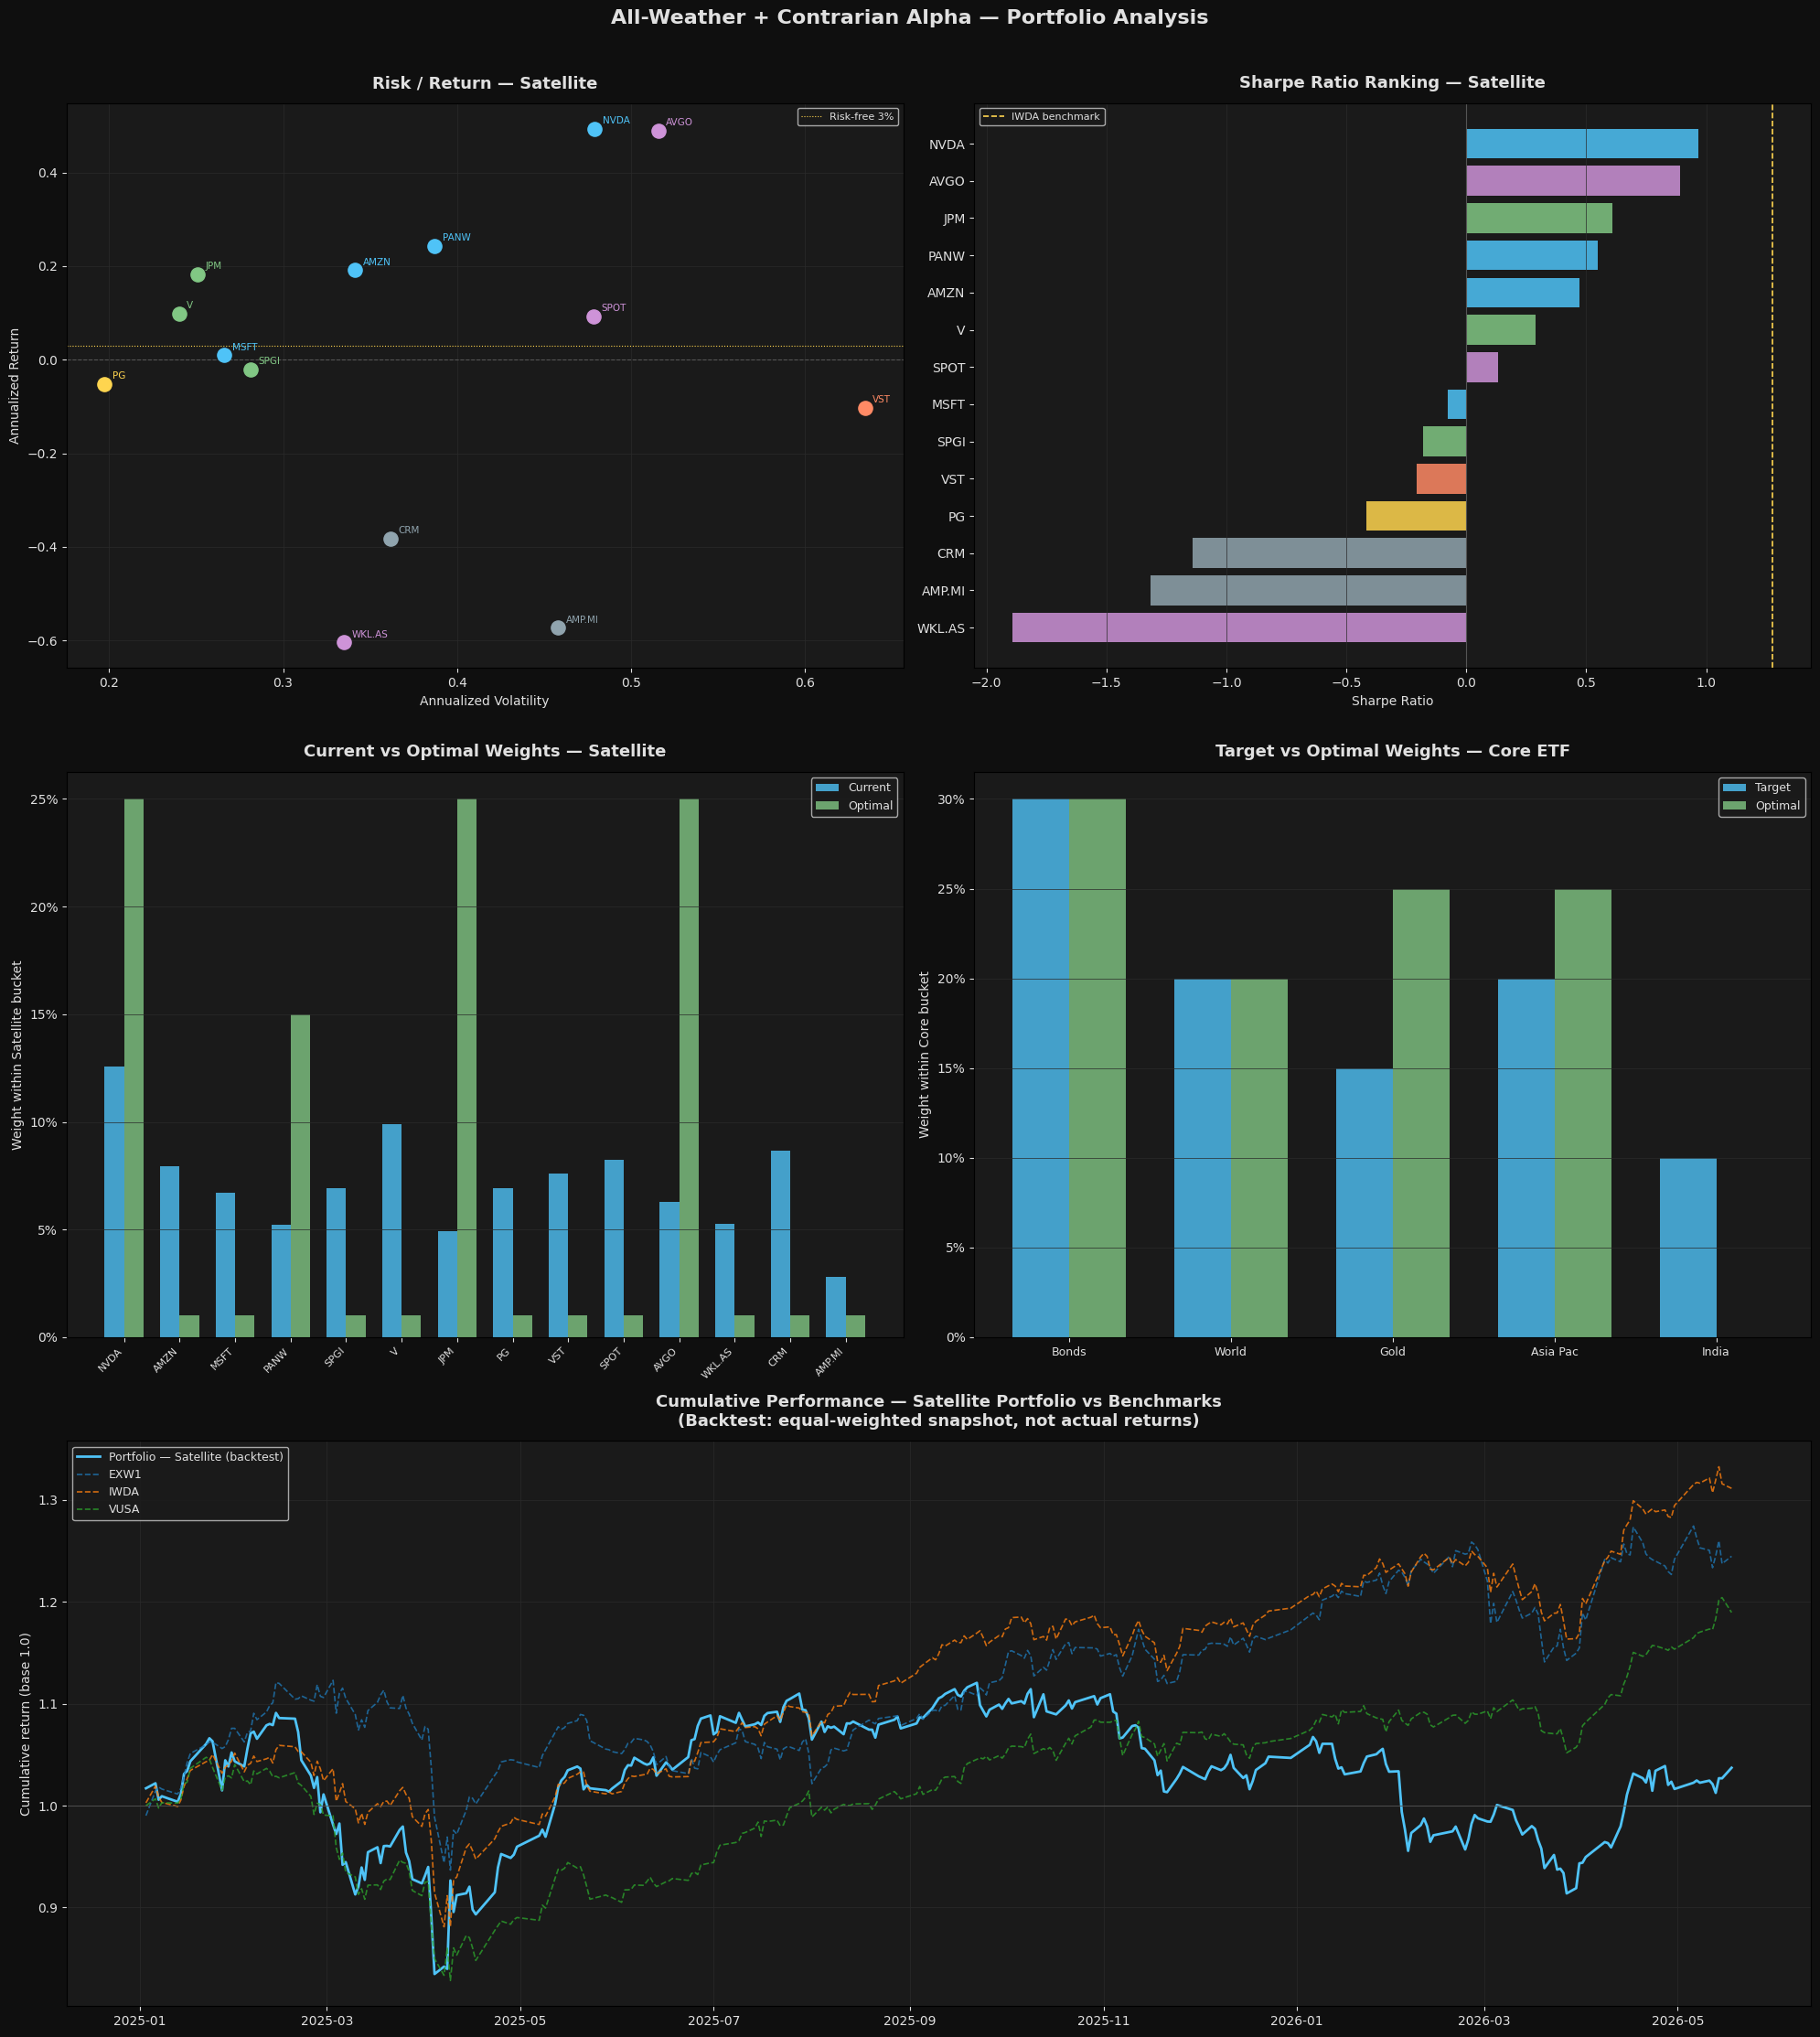


✓ Charts generated and saved as portfolio_analysis.png


In [7]:
# ── CELL 6 — VISUALIZATION ───────────────────────────────────
# Five charts covering risk/return, Sharpe ranking,
# weight comparison (Satellite and Core), and cumulative performance.

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#0f0f0f")

BG_DARK   = "#0f0f0f"
BG_PANEL  = "#1a1a1a"
TEXT      = "#e0e0e0"
GRID      = "#2a2a2a"

plt.rcParams.update({
    "text.color":       TEXT,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "axes.facecolor":   BG_PANEL,
    "figure.facecolor": BG_DARK,
})

GROUP_COLORS = {
    "Tech Pillar":       "#4FC3F7",
    "Financial Pillar":  "#81C784",
    "Defensive Pillar":  "#FFD54F",
    "Energy Pillar":     "#FF8A65",
    "Sergeants":         "#CE93D8",
    "Soldiers":          "#90A4AE",
    "ETF Core":          "#4DB6AC",
    "Benchmark":         "#616161",
}

BAR_CURRENT = "#4FC3F7"
BAR_OPTIMAL = "#81C784"
BAR_WIDTH   = 0.35

# ── Chart 1: Risk / Return scatter (Satellite) ────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(BG_PANEL)
ax1.set_title("Risk / Return — Satellite",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)

for ticker in equity_tickers:
    row   = metrics.loc[ticker]
    color = GROUP_COLORS.get(row["Group"], "#ffffff")
    ax1.scatter(row["Volatility"], row["Return"],
                color=color, s=120, zorder=5)
    ax1.annotate(ticker, (row["Volatility"], row["Return"]),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=7.5, color=color)

ax1.axhline(0, color="#555555", linewidth=0.8, linestyle="--")
ax1.axhline(RISK_FREE_RATE, color="#FFD54F", linewidth=0.8,
            linestyle=":", label=f"Risk-free {RISK_FREE_RATE:.0%}")
ax1.set_xlabel("Annualized Volatility")
ax1.set_ylabel("Annualized Return")
ax1.legend(fontsize=8)
ax1.grid(True, color=GRID, linewidth=0.5)

# ── Chart 2: Sharpe ranking (Satellite) ──────────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor(BG_PANEL)
ax2.set_title("Sharpe Ratio Ranking — Satellite",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)

sat_sharpe  = (metrics[metrics["Category"] == "Satellite"]
               [["Sharpe", "Group"]].sort_values("Sharpe"))
bar_colors  = [GROUP_COLORS.get(g, "#ffffff") for g in sat_sharpe["Group"]]
ax2.barh(sat_sharpe.index, sat_sharpe["Sharpe"],
         color=bar_colors, alpha=0.85)
ax2.axvline(0, color="#555555", linewidth=0.8)
ax2.axvline(metrics.loc["IWDA.L", "Sharpe"],
            color="#FFD54F", linewidth=1.2, linestyle="--",
            label="IWDA benchmark")
ax2.set_xlabel("Sharpe Ratio")
ax2.legend(fontsize=8)
ax2.grid(True, axis="x", color=GRID, linewidth=0.5)

# ── Chart 3: Current vs Optimal weights (Satellite) ──────────
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(BG_PANEL)
ax3.set_title("Current vs Optimal Weights — Satellite",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)

codes       = list(TICKER_MAP.keys())
tickers_ord = list(TICKER_MAP.values())
w_current   = [CURRENT_WEIGHTS.get(c, 0) for c in codes]
w_optimal   = list(optimal_weights_sat)

x = np.arange(len(codes))
ax3.bar(x - BAR_WIDTH / 2, w_current, BAR_WIDTH,
        label="Current", color=BAR_CURRENT, alpha=0.8)
ax3.bar(x + BAR_WIDTH / 2, w_optimal, BAR_WIDTH,
        label="Optimal", color=BAR_OPTIMAL, alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(tickers_ord, rotation=45, ha="right", fontsize=8)
ax3.set_ylabel("Weight within Satellite bucket")
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax3.legend(fontsize=9)
ax3.grid(True, axis="y", color=GRID, linewidth=0.5)

# ── Chart 4: Target vs Optimal weights (Core) ─────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor(BG_PANEL)
ax4.set_title("Target vs Optimal Weights — Core ETF",
              color=TEXT, fontsize=13, fontweight="bold", pad=12)

etf_labels   = ["Bonds", "World", "Gold", "Asia Pac", "India"]
target_core  = [v["target"] / TARGET_CORE for v in ETF_MAP.values()]
x2 = np.arange(len(etf_labels))
ax4.bar(x2 - BAR_WIDTH / 2, target_core, BAR_WIDTH,
        label="Target", color=BAR_CURRENT, alpha=0.8)
ax4.bar(x2 + BAR_WIDTH / 2, optimal_weights_core, BAR_WIDTH,
        label="Optimal", color=BAR_OPTIMAL, alpha=0.8)
ax4.set_xticks(x2)
ax4.set_xticklabels(etf_labels, fontsize=9)
ax4.set_ylabel("Weight within Core bucket")
ax4.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax4.legend(fontsize=9)
ax4.grid(True, axis="y", color=GRID, linewidth=0.5)

# ── Chart 5: Cumulative performance vs benchmarks ─────────────
ax5 = fig.add_subplot(3, 1, 3)
ax5.set_facecolor(BG_PANEL)
ax5.set_title(
    "Cumulative Performance — Satellite Portfolio vs Benchmarks\n"
    "(Backtest: equal-weighted snapshot, not actual returns)",
    color=TEXT, fontsize=13, fontweight="bold", pad=12)

weight_vector     = np.array([CURRENT_WEIGHTS.get(c, 0) for c in codes])
daily_portfolio   = returns[equity_tickers].dot(weight_vector)
cumulative_port   = (1 + daily_portfolio).cumprod()

ax5.plot(cumulative_port.index, cumulative_port.values,
         color="#4FC3F7", linewidth=2,
         label="Portfolio — Satellite (backtest)")

for bench_code, bench_ticker in BENCHMARK_MAP.items():
    cum_bench = (1 + returns[bench_ticker]).cumprod()
    ax5.plot(cum_bench.index, cum_bench.values,
             linewidth=1.2, linestyle="--", label=bench_code, alpha=0.8)

ax5.axhline(1.0, color="#555555", linewidth=0.6)
ax5.set_ylabel("Cumulative return (base 1.0)")
ax5.legend(fontsize=9)
ax5.grid(True, color=GRID, linewidth=0.5)

# ── Final layout and export ───────────────────────────────────
plt.suptitle(
    "All-Weather + Contrarian Alpha — Portfolio Analysis",
    color=TEXT, fontsize=16, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("portfolio_analysis.png", dpi=150,
            bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("\n✓ Charts generated and saved as portfolio_analysis.png")

Running bootstrap — this takes ~5 seconds...

═══ PORTFOLIO SHARPE — 95% CONFIDENCE INTERVAL ═══════════

  Bootstrap samples : 10,000
  Trading days used : 309

  Current weights
    Point estimate : +0.109
    95% CI         : [-1.655  →  +1.883]
    CI width       : 3.538  ⚠ noisy — interpret with caution

  Optimal weights
    Point estimate : +0.936
    95% CI         : [-0.865  →  +2.677]
    CI width       : 3.542  ⚠ noisy — interpret with caution

═══ INDIVIDUAL TICKER SHARPE — 95% CI ════════════════════

  Ticker       Point   CI Low  CI High   Width  Signal  
  ──────────────────────────────────────────────────────────────
  NVDA        +0.968   -0.790   +2.773   3.563  Uncertain ~
  AMZN        +0.473   -1.341   +2.219   3.560  Uncertain ~
  MSFT        -0.076   -1.841   +1.696   3.537  Uncertain ~
  PANW        +0.551   -1.242   +2.342   3.584  Uncertain ~
  SPGI        -0.181   -1.841   +1.692   3.534  Uncertain ~
  V           +0.288   -1.485   +2.079   3.565  Uncertain 

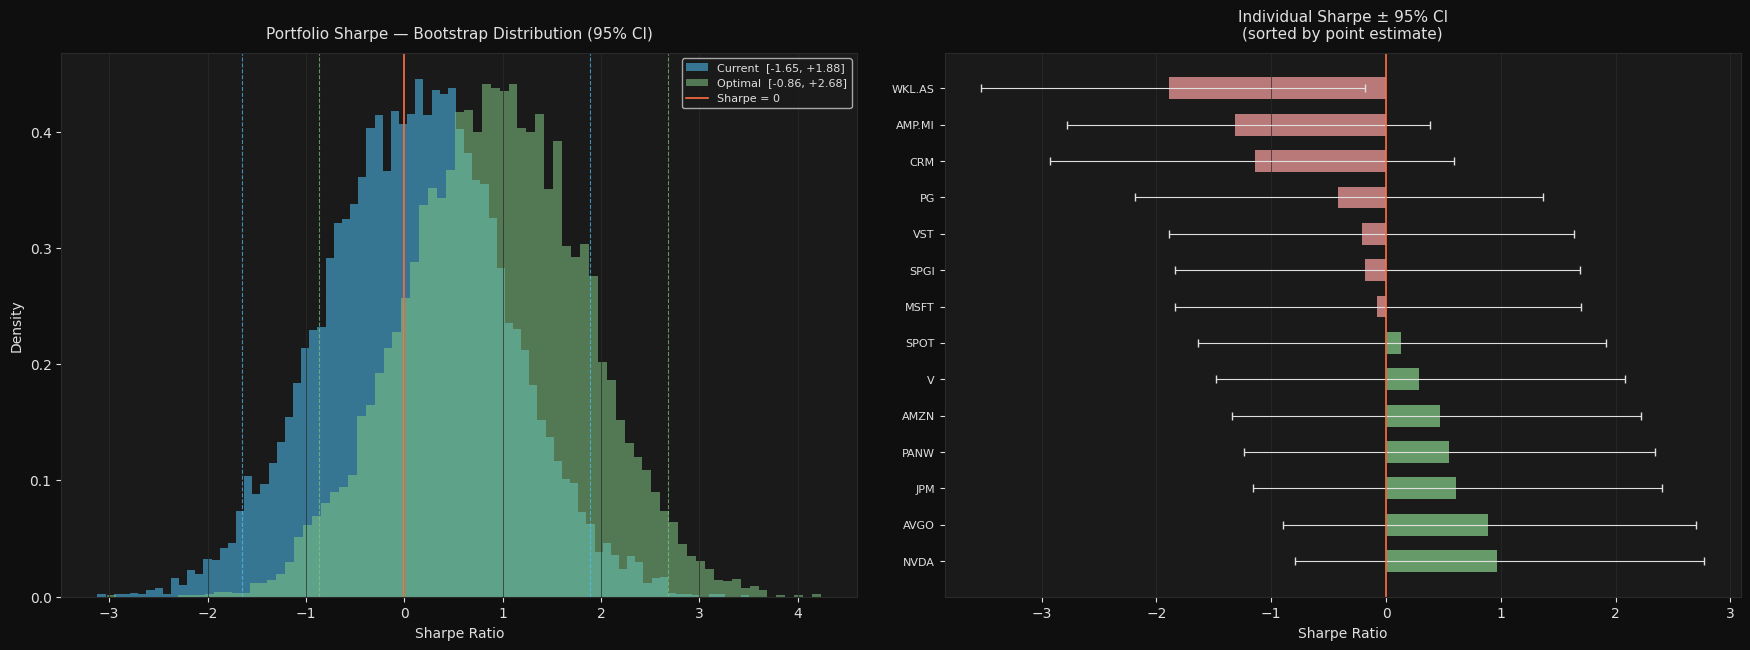


✓ Bootstrap CI complete. Chart saved as bootstrap_confidence_intervals.png

Interpretation guide:
  CI width < 0.8  → point estimate is relatively reliable
  CI width > 1.2  → too few observations to trust the number
  Zero inside CI  → Sharpe direction itself is statistically uncertain


In [8]:
# ── CELL 7 — BOOTSTRAP CONFIDENCE INTERVALS ──────────────────
# Quantifies the statistical uncertainty around Sharpe ratios.
#
# Method: resample daily returns 10,000 times with replacement,
# recompute Sharpe each time, read 2.5th and 97.5th percentiles
# as the 95% confidence interval.
#
# Why this matters: all metrics in Cell 4 are point estimates on
# ~309 trading days. The CI shows how much to trust each number.
# A wide CI means the metric is noisy — the true value could be
# very different from what the data suggests.

N_BOOTSTRAP = 10_000
np.random.seed(42)   # reproducibility: same results every run

print("Running bootstrap — this takes ~5 seconds...\n")


# ── Helper functions ──────────────────────────────────────────

def sharpe_from_array(r: np.ndarray) -> float:
    """Annualized Sharpe from a 1-D array of daily returns."""
    ann_ret = r.mean() * TRADING_DAYS
    ann_vol = r.std()  * np.sqrt(TRADING_DAYS)
    return (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0.0


def bootstrap_portfolio_sharpe(ret_matrix: np.ndarray,
                                weights: np.ndarray,
                                n: int = N_BOOTSTRAP) -> np.ndarray:
    """
    Vectorized bootstrap for a weighted portfolio.
    ret_matrix : shape (n_days, n_assets)
    weights    : shape (n_assets,)
    Returns    : array of n Sharpe values
    """
    n_days = ret_matrix.shape[0]
    # Draw n samples of n_days rows each (with replacement)
    idx     = np.random.randint(0, n_days, size=(n, n_days))
    samples = ret_matrix[idx]          # (n, n_days, n_assets)
    port_r  = samples @ weights        # (n, n_days)
    ann_ret = port_r.mean(axis=1) * TRADING_DAYS
    ann_vol = port_r.std(axis=1)  * np.sqrt(TRADING_DAYS)
    return (ann_ret - RISK_FREE_RATE) / ann_vol


def bootstrap_single_sharpe(r: np.ndarray,
                             n: int = N_BOOTSTRAP) -> np.ndarray:
    """Bootstrap Sharpe for a single return series."""
    n_days  = len(r)
    idx     = np.random.randint(0, n_days, size=(n, n_days))
    samples = r[idx]                   # (n, n_days)
    ann_ret = samples.mean(axis=1) * TRADING_DAYS
    ann_vol = samples.std(axis=1)  * np.sqrt(TRADING_DAYS)
    return (ann_ret - RISK_FREE_RATE) / ann_vol


# ── Build current weight vector (same order as equity_tickers) ─
current_weights_array = np.array([
    CURRENT_WEIGHTS.get(
        next(k for k, v in TICKER_MAP.items() if v == t), 0.0
    )
    for t in equity_tickers
])
current_weights_array /= current_weights_array.sum()   # normalize within bucket

sat_ret_matrix = sat_returns.values   # (n_days, 14) — already computed in Cell 5


# ── Section 1: Portfolio-level CI ─────────────────────────────
print("═══ PORTFOLIO SHARPE — 95% CONFIDENCE INTERVAL ═══════════\n")
print(f"  Bootstrap samples : {N_BOOTSTRAP:,}")
print(f"  Trading days used : {sat_ret_matrix.shape[0]}\n")

bs_current = bootstrap_portfolio_sharpe(sat_ret_matrix, current_weights_array)
bs_optimal = bootstrap_portfolio_sharpe(sat_ret_matrix, optimal_weights_sat)

for label, bs in [("Current weights", bs_current), ("Optimal weights", bs_optimal)]:
    pt       = sharpe_from_array(sat_ret_matrix @ (
                   current_weights_array if "Current" in label else optimal_weights_sat))
    lo, hi   = np.percentile(bs, [2.5, 97.5])
    width    = hi - lo
    reliable = "✓ reliable" if width < 0.8 else "⚠ noisy — interpret with caution"

    print(f"  {label}")
    print(f"    Point estimate : {pt:+.3f}")
    print(f"    95% CI         : [{lo:+.3f}  →  {hi:+.3f}]")
    print(f"    CI width       : {width:.3f}  {reliable}\n")


# ── Section 2: Individual ticker CI ───────────────────────────
print("═══ INDIVIDUAL TICKER SHARPE — 95% CI ════════════════════\n")
print(f"  {'Ticker':<10} {'Point':>7}  {'CI Low':>7}  {'CI High':>7}  "
      f"{'Width':>6}  {'Signal'}  ")
print("  " + "─" * 62)

ticker_ci_data = {}

for ticker in equity_tickers:
    r      = sat_returns[ticker].values
    bs     = bootstrap_single_sharpe(r)
    pt     = sharpe_from_array(r)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    width  = hi - lo

    # Signal: is zero inside the CI? If yes, we can't even confirm
    # the direction of the Sharpe with statistical confidence.
    if lo > 0:
        signal = "Positive ✓"
    elif hi < 0:
        signal = "Negative ✗"
    else:
        signal = "Uncertain ~"

    ticker_ci_data[ticker] = {"point": pt, "lo": lo, "hi": hi, "width": width}
    print(f"  {ticker:<10} {pt:>+7.3f}  {lo:>+7.3f}  {hi:>+7.3f}  "
          f"{width:>6.3f}  {signal}")


# ── Section 3: Visualization ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f0f")

BG_PANEL = "#1a1a1a"
TEXT     = "#e0e0e0"
GRID     = "#2a2a2a"

plt.rcParams.update({
    "text.color":       TEXT,
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "axes.facecolor":   BG_PANEL,
    "figure.facecolor": "#0f0f0f",
})


# -- Chart A: Portfolio Sharpe distribution (current vs optimal) --
ax = axes[0]
ax.set_facecolor(BG_PANEL)

lo_c, hi_c = np.percentile(bs_current, [2.5, 97.5])
lo_o, hi_o = np.percentile(bs_optimal, [2.5, 97.5])

ax.hist(bs_current, bins=80, alpha=0.55, color="#4FC3F7",
        label=f"Current  [{lo_c:+.2f}, {hi_c:+.2f}]", density=True)
ax.hist(bs_optimal, bins=80, alpha=0.55, color="#81C784",
        label=f"Optimal  [{lo_o:+.2f}, {hi_o:+.2f}]", density=True)

for val, col in [(lo_c, "#4FC3F7"), (hi_c, "#4FC3F7"),
                 (lo_o, "#81C784"), (hi_o, "#81C784")]:
    ax.axvline(val, color=col, linewidth=0.8, linestyle="--", alpha=0.7)

ax.axvline(0, color="#FF7043", linewidth=1.2, linestyle="-", label="Sharpe = 0")
ax.set_title("Portfolio Sharpe — Bootstrap Distribution (95% CI)",
             color=TEXT, fontsize=11, pad=10)
ax.set_xlabel("Sharpe Ratio", color=TEXT)
ax.set_ylabel("Density", color=TEXT)
ax.legend(fontsize=8, facecolor="#1a1a1a", labelcolor=TEXT)
ax.grid(axis="x", color=GRID, linewidth=0.5)
ax.spines[:].set_color(GRID)


# -- Chart B: Individual ticker CI (error bar chart) ---------------
ax2 = axes[1]
ax2.set_facecolor(BG_PANEL)

tickers_sorted = sorted(ticker_ci_data.keys(),
                        key=lambda t: ticker_ci_data[t]["point"], reverse=True)

points = [ticker_ci_data[t]["point"] for t in tickers_sorted]
lows   = [ticker_ci_data[t]["point"] - ticker_ci_data[t]["lo"]  for t in tickers_sorted]
highs  = [ticker_ci_data[t]["hi"]  - ticker_ci_data[t]["point"] for t in tickers_sorted]

colors = ["#81C784" if p > 0 else "#EF9A9A" for p in points]

y_pos = range(len(tickers_sorted))
ax2.barh(y_pos, points, xerr=[lows, highs], color=colors, alpha=0.75,
         ecolor=TEXT, capsize=3, height=0.6, error_kw={"linewidth": 0.8})
ax2.axvline(0, color="#FF7043", linewidth=1.2)

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(tickers_sorted, fontsize=8)
ax2.set_title("Individual Sharpe ± 95% CI\n(sorted by point estimate)",
              color=TEXT, fontsize=11, pad=10)
ax2.set_xlabel("Sharpe Ratio", color=TEXT)
ax2.grid(axis="x", color=GRID, linewidth=0.5)
ax2.spines[:].set_color(GRID)

plt.tight_layout(pad=2.5)
plt.savefig("bootstrap_confidence_intervals.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

print("\n✓ Bootstrap CI complete. Chart saved as bootstrap_confidence_intervals.png")
print("\nInterpretation guide:")
print("  CI width < 0.8  → point estimate is relatively reliable")
print("  CI width > 1.2  → too few observations to trust the number")
print("  Zero inside CI  → Sharpe direction itself is statistically uncertain")